## House Price Prediction Model

### 1. Load and Explore Data

In [19]:
import pandas as pd
df = pd.read_csv("House_Price_Prediction_Dataset.csv")

In [20]:
print(df.shape)

(2000, 10)


In [21]:
print(df.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB
None


In [23]:
print(df.describe())

                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  999656.000000  


### 2. Data Cleaning & Preprocessing

In [24]:
df = df.drop('Id', axis=1)

In [25]:
print(df['Location'].unique())
print(df['Condition'].unique())
print(df['Garage'].unique())

<StringArray>
['Downtown', 'Suburban', 'Urban', 'Rural']
Length: 4, dtype: str
<StringArray>
['Excellent', 'Good', 'Fair', 'Poor']
Length: 4, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [26]:
X = df.drop('Price', axis=1)
y = df['Price']

In [27]:
X = pd.get_dummies(X, columns=['Location', 'Condition', 'Garage'], drop_first=True)

### 3. Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4. Model Training (Linear Regression)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ -0.58, 76.78, -9662.25,...,-12941.04, 4073.27, 2373.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Area','Bedrooms','Bathrooms',...,'Condition_Good','Condition_Poor', 'Garage_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.785e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


### 5. Model Evaluation

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 243241.97758826384
RMSE: 279859.72583784326
R² Score: -0.006717808430749761


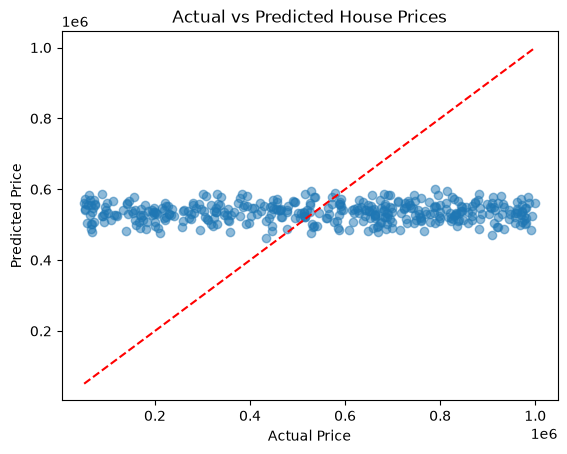

In [31]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [32]:
coeffs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print(coeffs)

Condition_Fair       24083.307846
Floors               23727.983633
Location_Suburban    11511.989815
Condition_Poor        4073.268930
Garage_Yes            2373.530579
Location_Rural        1317.542020
YearBuilt              117.613885
Bedrooms                76.784827
Area                    -0.575754
Bathrooms            -9662.248234
Location_Urban      -12718.918912
Condition_Good      -12941.044835
dtype: float64


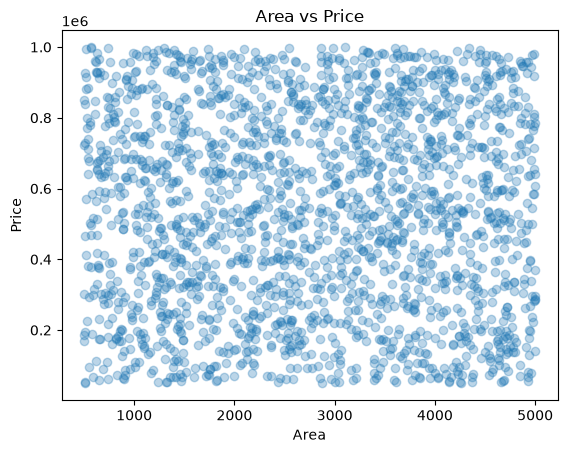

In [33]:
import matplotlib.pyplot as plt
plt.scatter(df['Area'], df['Price'], alpha=0.3)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

### 6. Model Comparison (Random Forest)

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R²:", r2_score(y_test, y_pred_rf))

RF MAE: 252518.030125
RF RMSE: 292059.8903646424
RF R²: -0.09640442128237403


## Conclusion

Both Linear Regression and Random Forest models were trained to predict house prices 
based on features like area, bedrooms, bathrooms, floors, year built, location, condition, 
and garage availability. Both models produced R² scores near zero, indicating minimal 
predictive relationship between these features and price in this dataset — likely because 
the data was synthetically generated without a strong underlying pattern. The project 
successfully demonstrates the full regression workflow: data cleaning, encoding, splitting, 
training, and evaluation.